# Evaluate metrics using running example

In [1]:
from approach_suffix_v2.metric_example import main

main()

Ground truth: A->{B,C,D}->E->{F,G}

Group        Case                    Prediction                  DL    GES  BO combined  BO order  BO content
-----------  ----------------------  -----------------------  -----  -----  -----------  --------  ----------
Sanity       Perfect                 A->{B,C,D}->E->{F,G}     1.000  1.000        1.000     1.000       1.000
Sanity       Within-block shuffle    A->{D,B,C}->E->{G,F}     0.571  1.000        1.000     1.000       1.000
Concurrency  All sequential          A->B->C->D->E->F->G      1.000  0.714        0.905     0.905       1.000
Concurrency  Single block            {A,B,C,D,E,F,G}          1.000  0.636        0.595     0.595       1.000
Concurrency  Block split             A->{B,C}->D->E->{F,G}    1.000  0.828        0.952     0.952       1.000
Concurrency  Block merge             A->{B,C,D,E}->{F,G}      1.000  0.706        0.929     0.929       1.000
Order        Blocks swapped          A->E->{B,C,D}->{F,G}     0.714  0.438        0.

$\textbf{BO order}$ It is the Kendall distance with p = ½. It looks only at the activities that appear in both the prediction and the true suffix, and asks whether they are arranged correctly. It takes every pair of those activities and checks how they relate in each version: one comes before the other, or both are in the same parallel block. If the relation matches, there's no penalty. If one version has them in the same block and the other puts them one after the other, the penalty is ½. If they come in opposite orders, the penalty is 1. The penalties are added up and divided by the worst possible total, so 1 means a perfect arrangement and 0 means everything reversed. Missing or extra activities don't affect this score.

$\textbf{BO content}$ ignores order completely and only asks whether the model predicted the right activities. It counts how many activities appear in both suffixes; a repeated activity counts once per occurrence. It then compares that count with the lengths of both suffixes using the usual F1 score, which balances precision (how many predicted activities are correct) against recall (how many true activities were predicted). Extra activities lower precision, missing ones lower recall, and the score is 1 only when the prediction contains exactly the right activities.

$\textbf{GES}$ turns each suffix into a small graph. Each activity is a node, and each node gets an arrow to every node in the next block. It then finds the cheapest set of edits that turns the predicted graph into the true one: changing a node's label, or adding or removing nodes and arrows. That number of edits is divided by the combined size of both graphs, so 1 means identical graphs and lower values mean more editing is needed. Because changing a label is cheap and arrows can be matched regardless of their labels, GES mainly rewards having the right shape. A prediction with the correct structure but completely wrong activities still scores fairly high.

# Compare with baselines

In [1]:
from approach_suffix_v2.generate_baseline_results import run

run()


=== Log: BPIC15_1 ===
          Model  Runs GES ↑ DL similarity ↑ MAE TTNE (min) ↓ MAE RRT (min) ↓ Next act acc ↑ Next act F1 (wt) ↑    # params
       SEP-LSTM     1  0.27            0.28          2991.31        48332.07           0.32               0.32 273618.0000
        ED-LSTM     1  0.22            0.21          2659.27        55370.99           0.12               0.12 295954.0000
CRTP-LSTM (NDA)     1  0.22            0.16          3692.77        37812.75           0.23               0.23 151698.0000
   SuTraN (NDA)     1  0.21            0.20          2640.82        37926.05           0.16               0.18 149619.0000
           BEST     1  0.21            0.17              N/A             N/A           0.23               0.25         NaN
       Graph_v1     1  0.20            0.12          3074.60        45404.53           0.15               0.16 122644.0000
    SuTraN (DA)     0   N/A             N/A              N/A             N/A            N/A                N/A      

/workspace/baselines/results_collector.py:65: RuntimeWarning: Mean of empty slice
  row[f"{col} mean"] = round(float(np.nanmean(values)), decimals)


# Ablation test 1: Input structure

Compare exactly same model, with the only difference been the input structure.

The Structure is: Graph, expected sequence and flipped sequence

In [15]:
from approach_suffix_v2.generate_ablation_results import run

run()


╔════════════════════════════════════════════════════════════════════════════════════════════════════╗
║  ABLATION: Input Format (Graph vs Seq vs Flip vs Random)                                           ║
╚════════════════════════════════════════════════════════════════════════════════════════════════════╝

  === Log: BPIC15_1 ===

  Results by input format
  ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Variant      │   N │       GES ↑ │    DL sim ↑ │ TTNE (min) ↓ │  RRT (min) ↓ │     NB F1 ↑ │    NB acc ↑ │   Step F1 ↑ │  Step acc ↑ │ # params
  ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  SeqRandom_v1 │   1 │        0.23 │        0.24 │         3009 │        46641 │        0.29 │        0.41 │        0.20 │        0.19 │   122644
  SeqFlip_v1   │   1 │        0.22 │        0.22 │    

# Ablation test 2: Compare different training strategies

In [1]:
from approach_suffix_v2.generate_ablation_train_results import run

run()


╔════════════════════════════════════════════════════════════════════════════════════════════════════╗
║  ABLATION: Training method (scheduled sampling × teacher forcing × next-activity)                  ║
╚════════════════════════════════════════════════════════════════════════════════════════════════════╝

  === Log: BPIC15_1 ===

  Results by training-method variant
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Variant                 │   N │       GES ↑ │    DL sim ↑ │     NB F1 ↑ │    NB acc ↑ │   Step F1 ↑ │  Step acc ↑ │ # params
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  v3 (next-activity only) │   5 │ 0.28 ± 0.01 │ 0.24 ± 0.02 │ 0.25 ± 0.01 │ 0.59 ± 0.02 │ 0.19 ± 0.04 │ 0.19 ± 0.04 │   122644
  v2 (teacher forcing)    │   5 │ 0.22 ± 0.02 │ 0.22 ± 0.02 │ 0.29 ± 0.00 │ 0.43 ± 0.01 │ 0.23 ± 0.04 │ 0.23 ± 0.05 │  

# Results: per prefix-suffix len

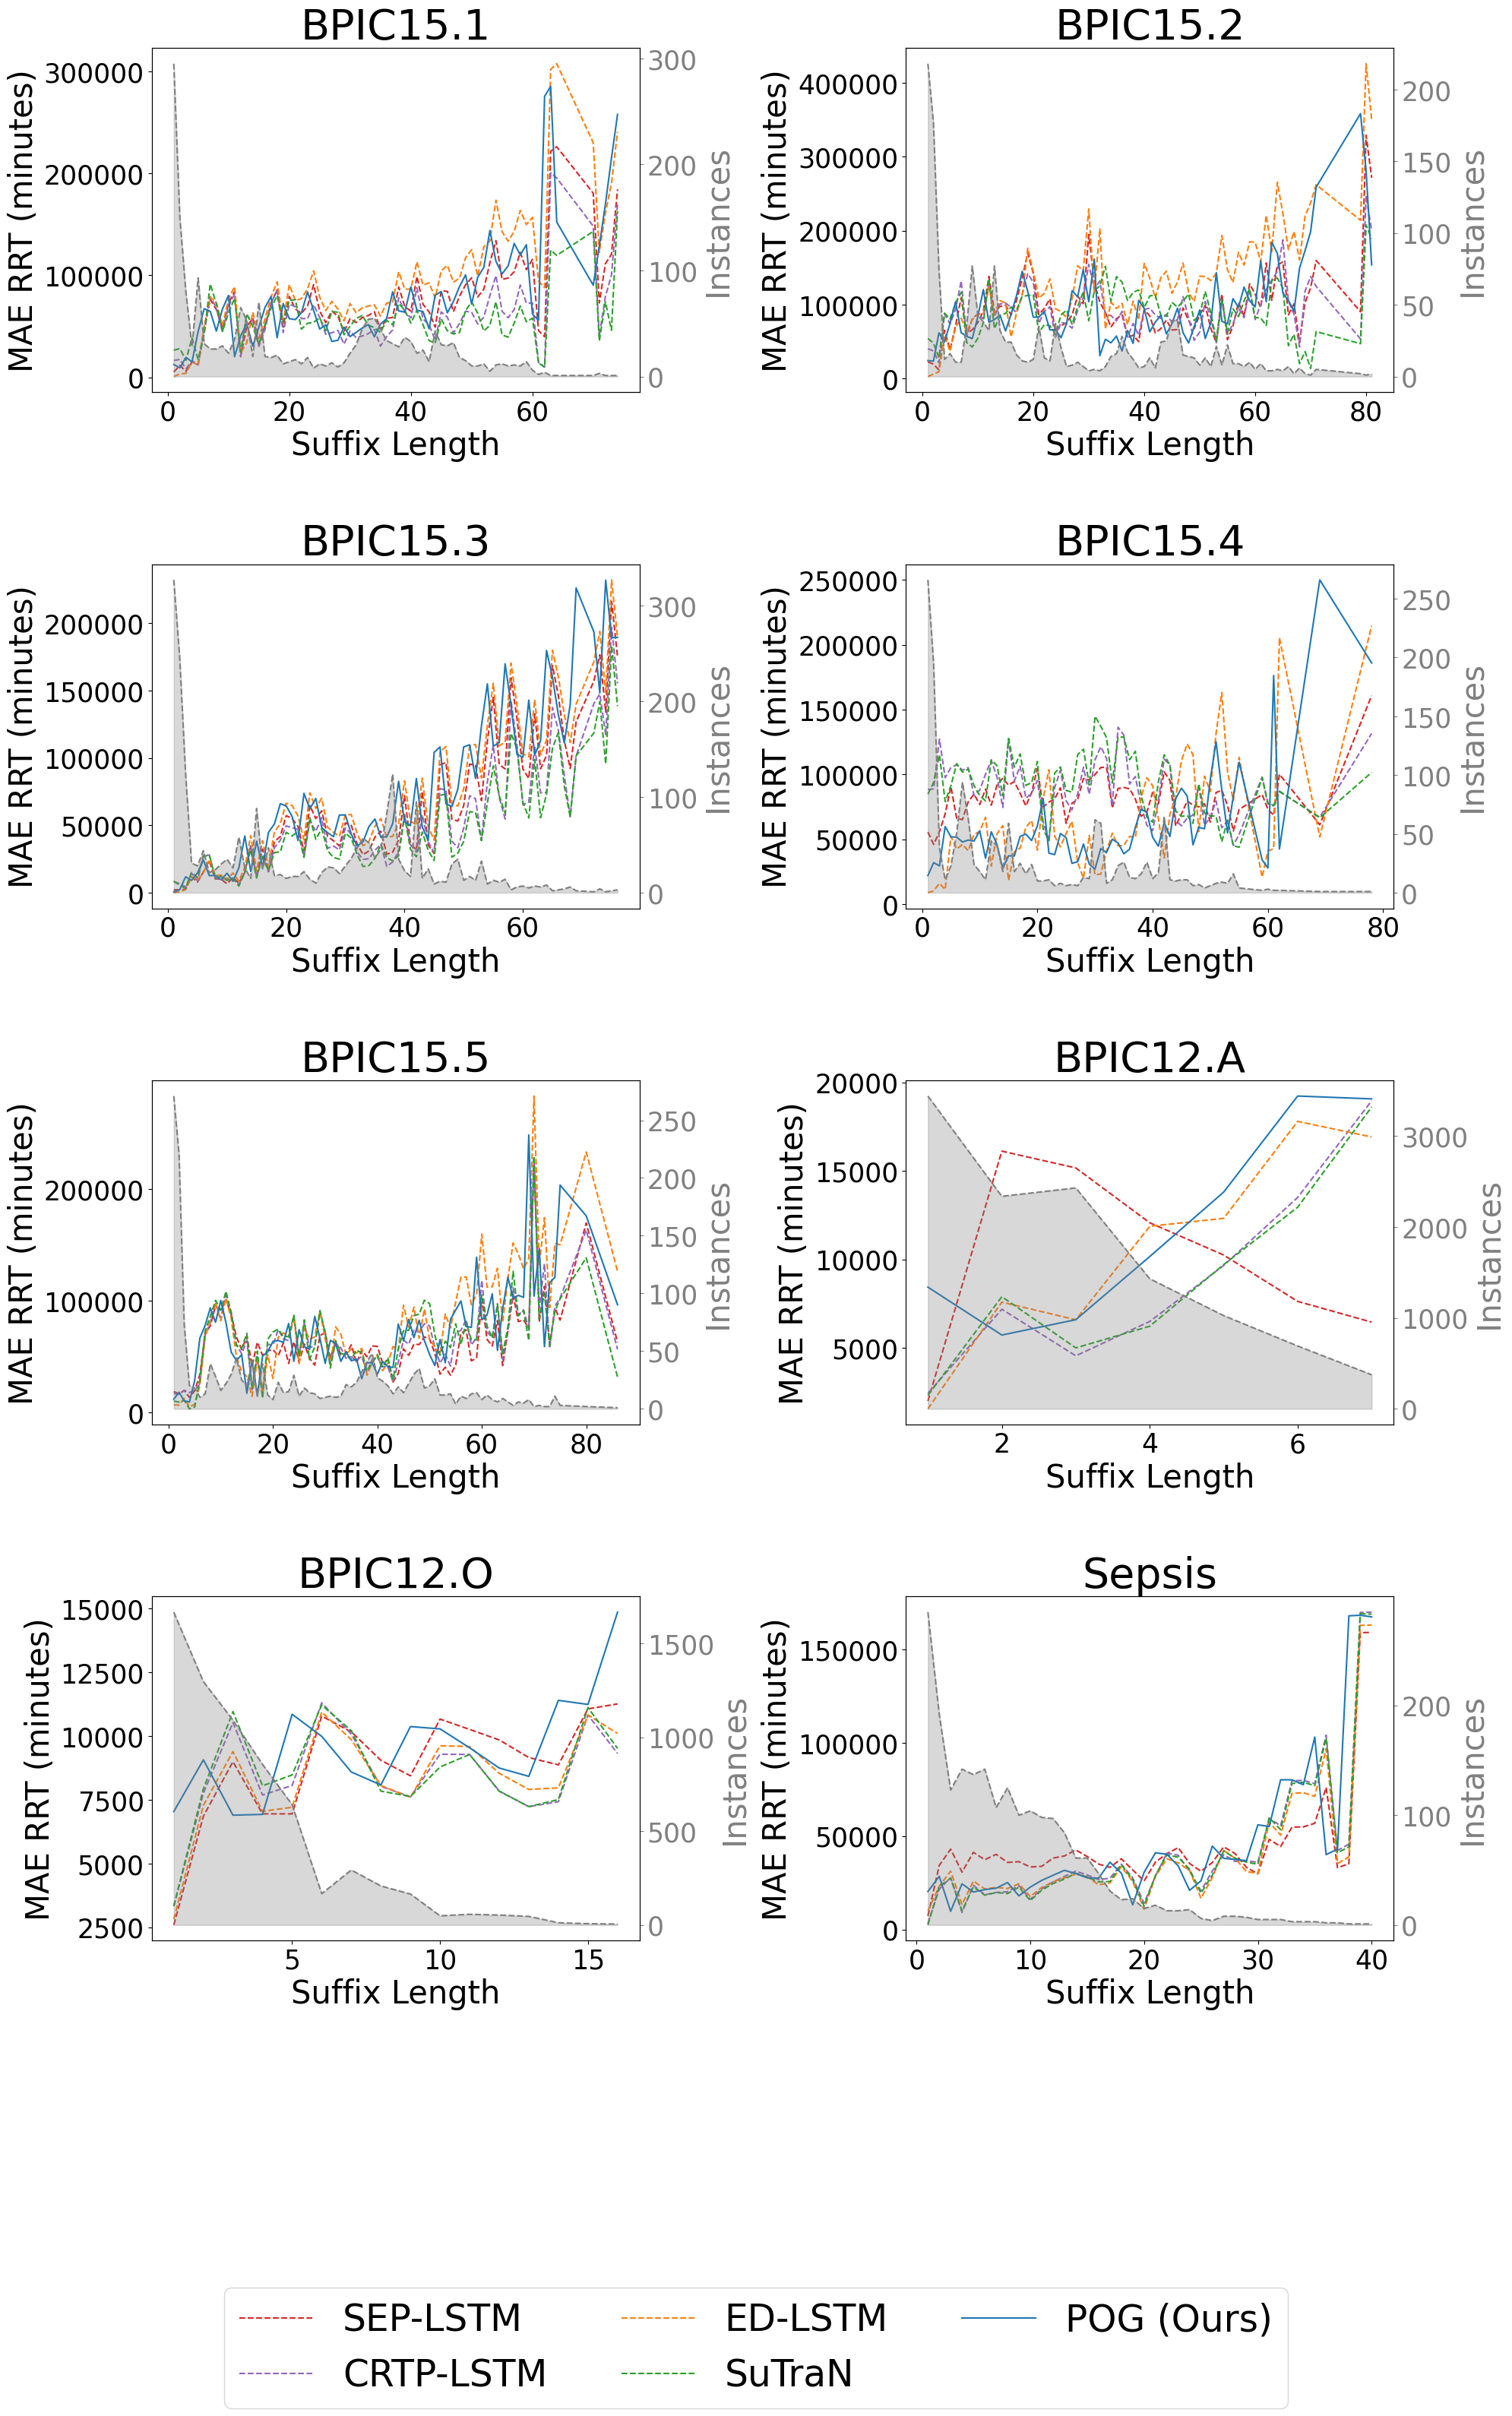

In [12]:
from approach_suffix_v2.visualization.pref_suf_plots_utils import plot_all_logs

EVENT_LOGS = [
    "BPIC15_1",
    "BPIC15_2",
    "BPIC15_3",
    "BPIC15_4",
    "BPIC15_5",
    "BPI_Challenge_2012_A",
    "BPI_Challenge_2012_O",
    "Sepsis",
]

plot_all_logs(
    log_names=EVENT_LOGS,
    baselines_root='baselines/SuffixTransformerNetwork',
    approach_results_base='approach_suffix_v2/results_time_gatv2_gru_nb_v4',
    save_path='approach_suffix_v2/ges_all_logs.png',
    metric='mae_rrt',
    length_axis='suffix',
    logs_per_row=2,
    approach_key='GATv2_GRU',
    run_ids=(1, 2, 3, 4, 5),
    baselines_to_include=None,
    )

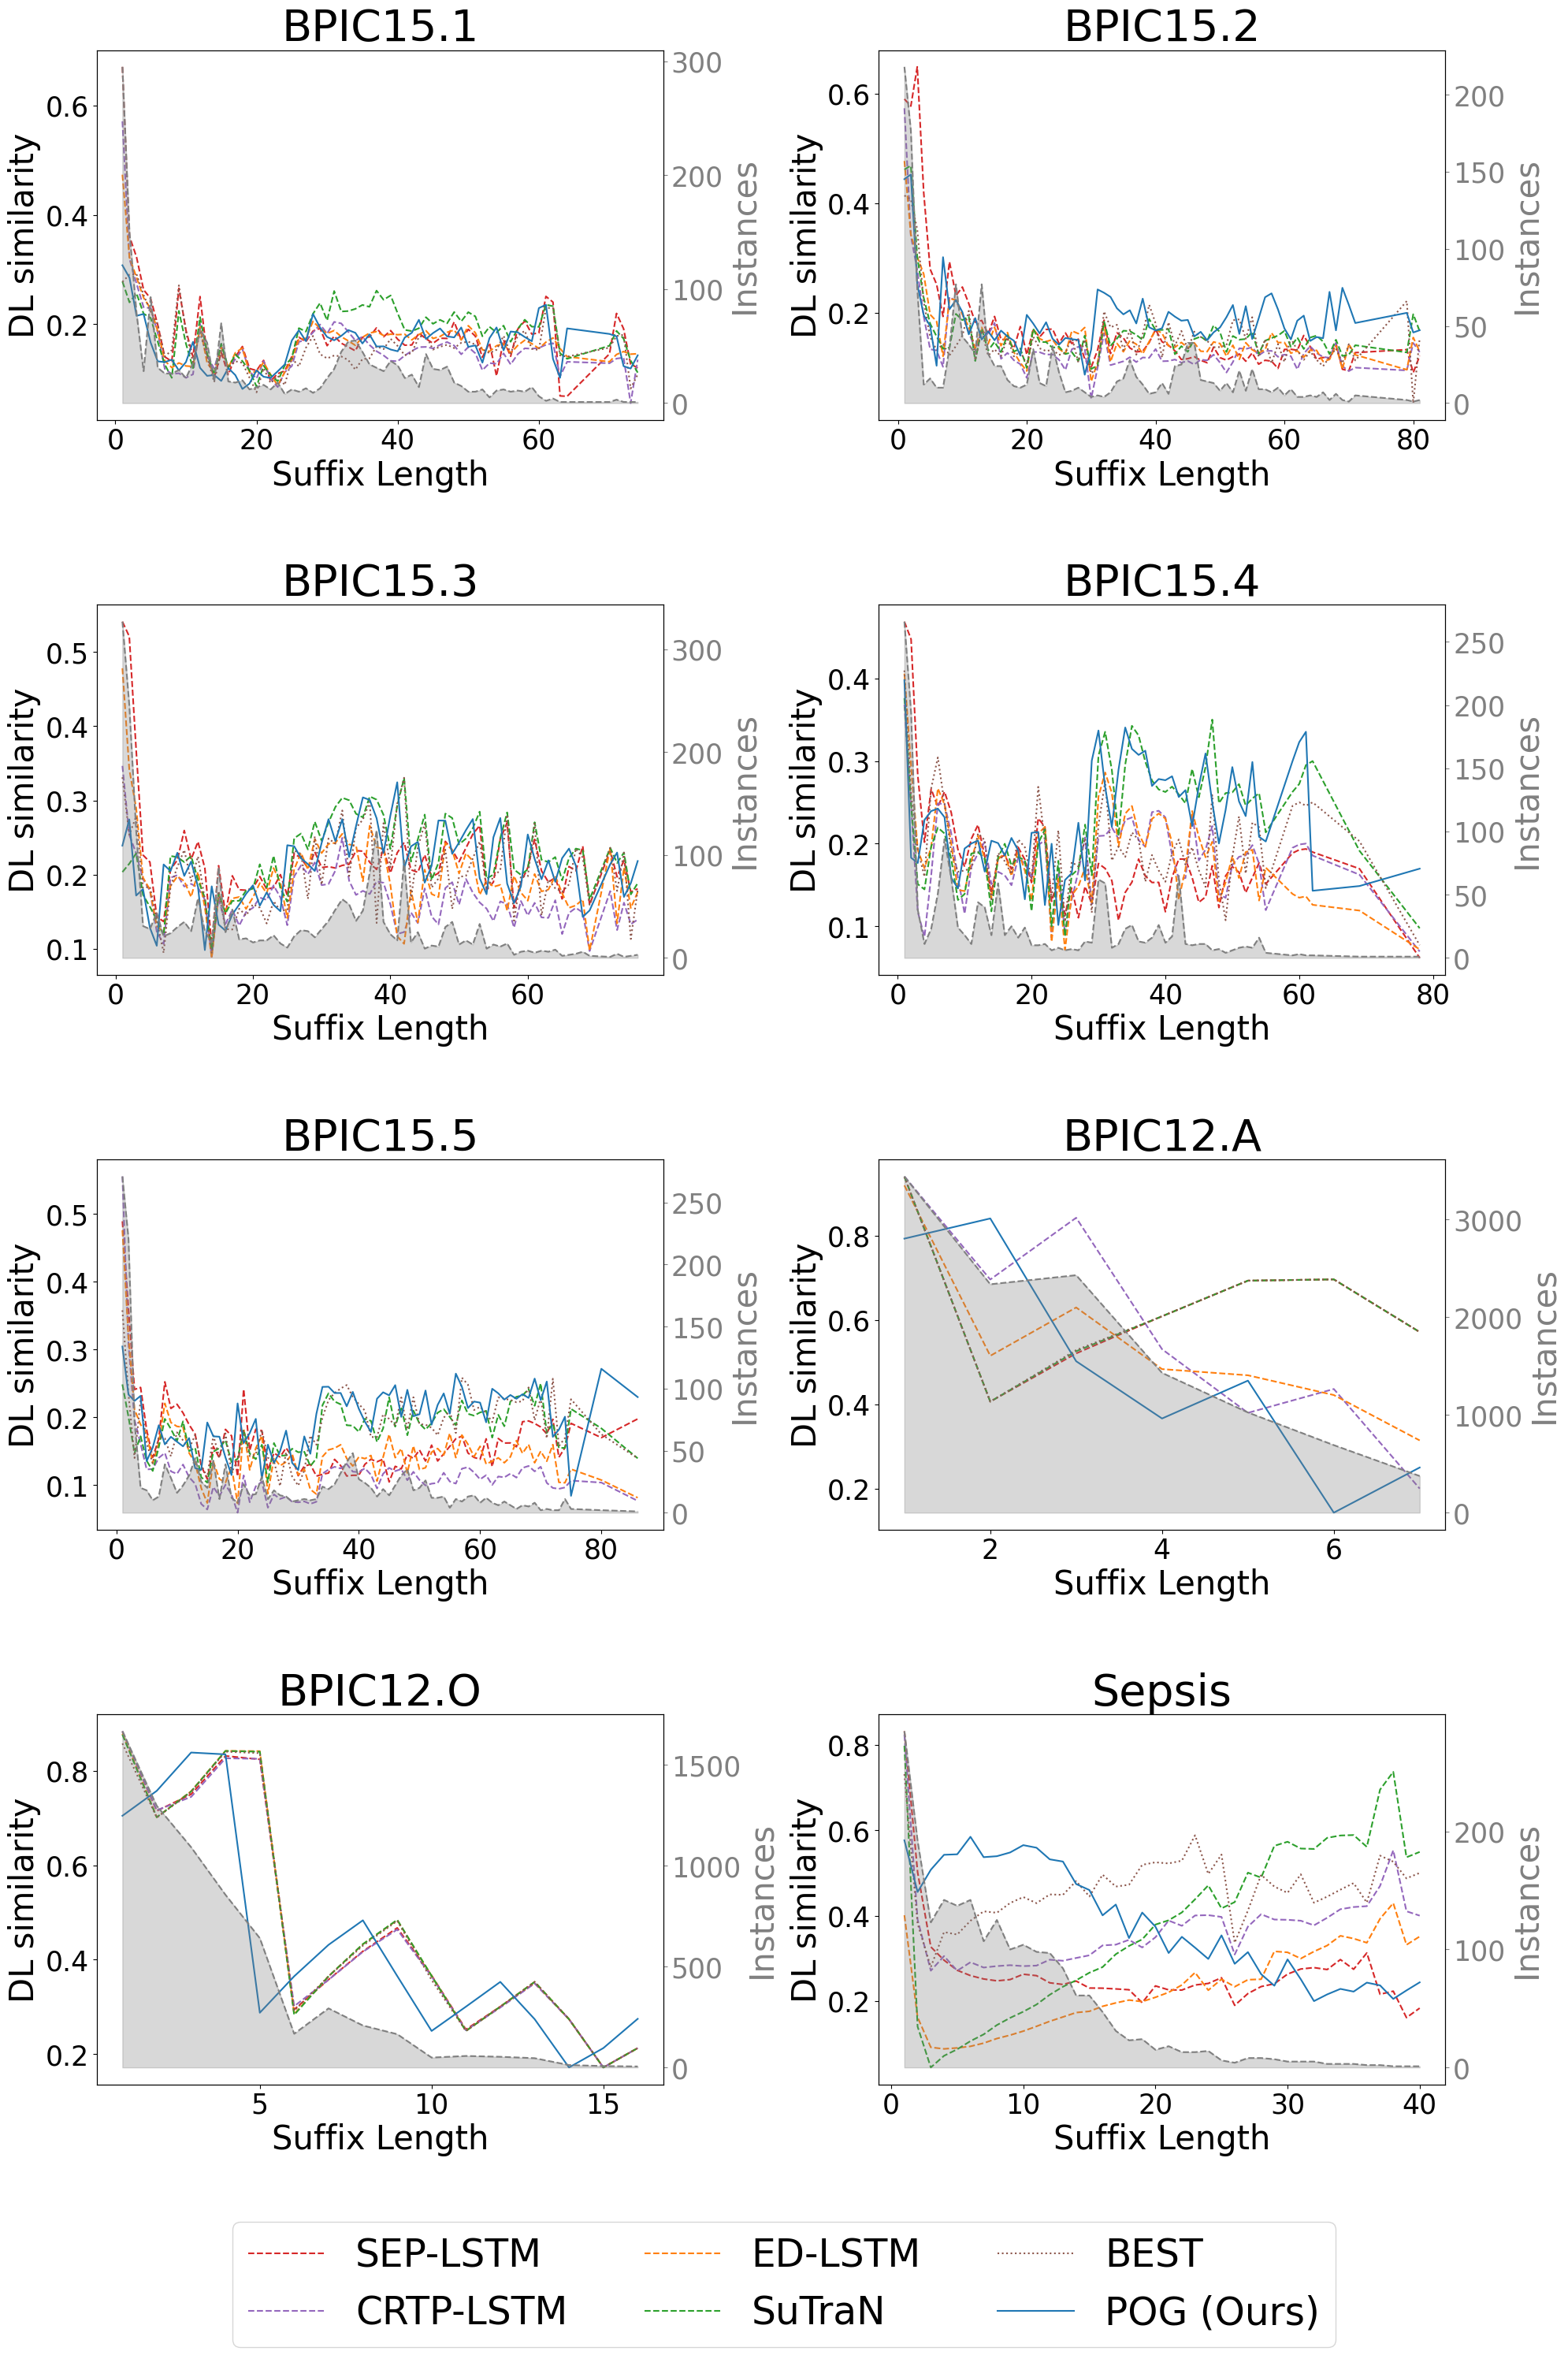

In [6]:
from approach_suffix_v2.visualization.pref_suf_plots_utils import plot_all_logs

EVENT_LOGS = [
    "BPIC15_1",
    "BPIC15_2",
    "BPIC15_3",
    "BPIC15_4",
    "BPIC15_5",
    "BPI_Challenge_2012_A",
    "BPI_Challenge_2012_O",
    "Sepsis",
]

plot_all_logs(
    log_names=EVENT_LOGS,
    baselines_root='baselines/SuffixTransformerNetwork',
    approach_results_base='approach_suffix_v2/results_time_gatv2_gru_nb_v4',
    save_path='approach_suffix_v2/dls_all_logs.png',
    metric='dl',
    length_axis='suffix',
    logs_per_row=2,
    approach_key='GATv2_GRU',
    run_ids=(1, 2, 3, 4, 5),
    baselines_to_include=None,
    )

The gray shaded area is the instance count for each length bucket. It shows how many test instances exist at each prefix (or suffix) length

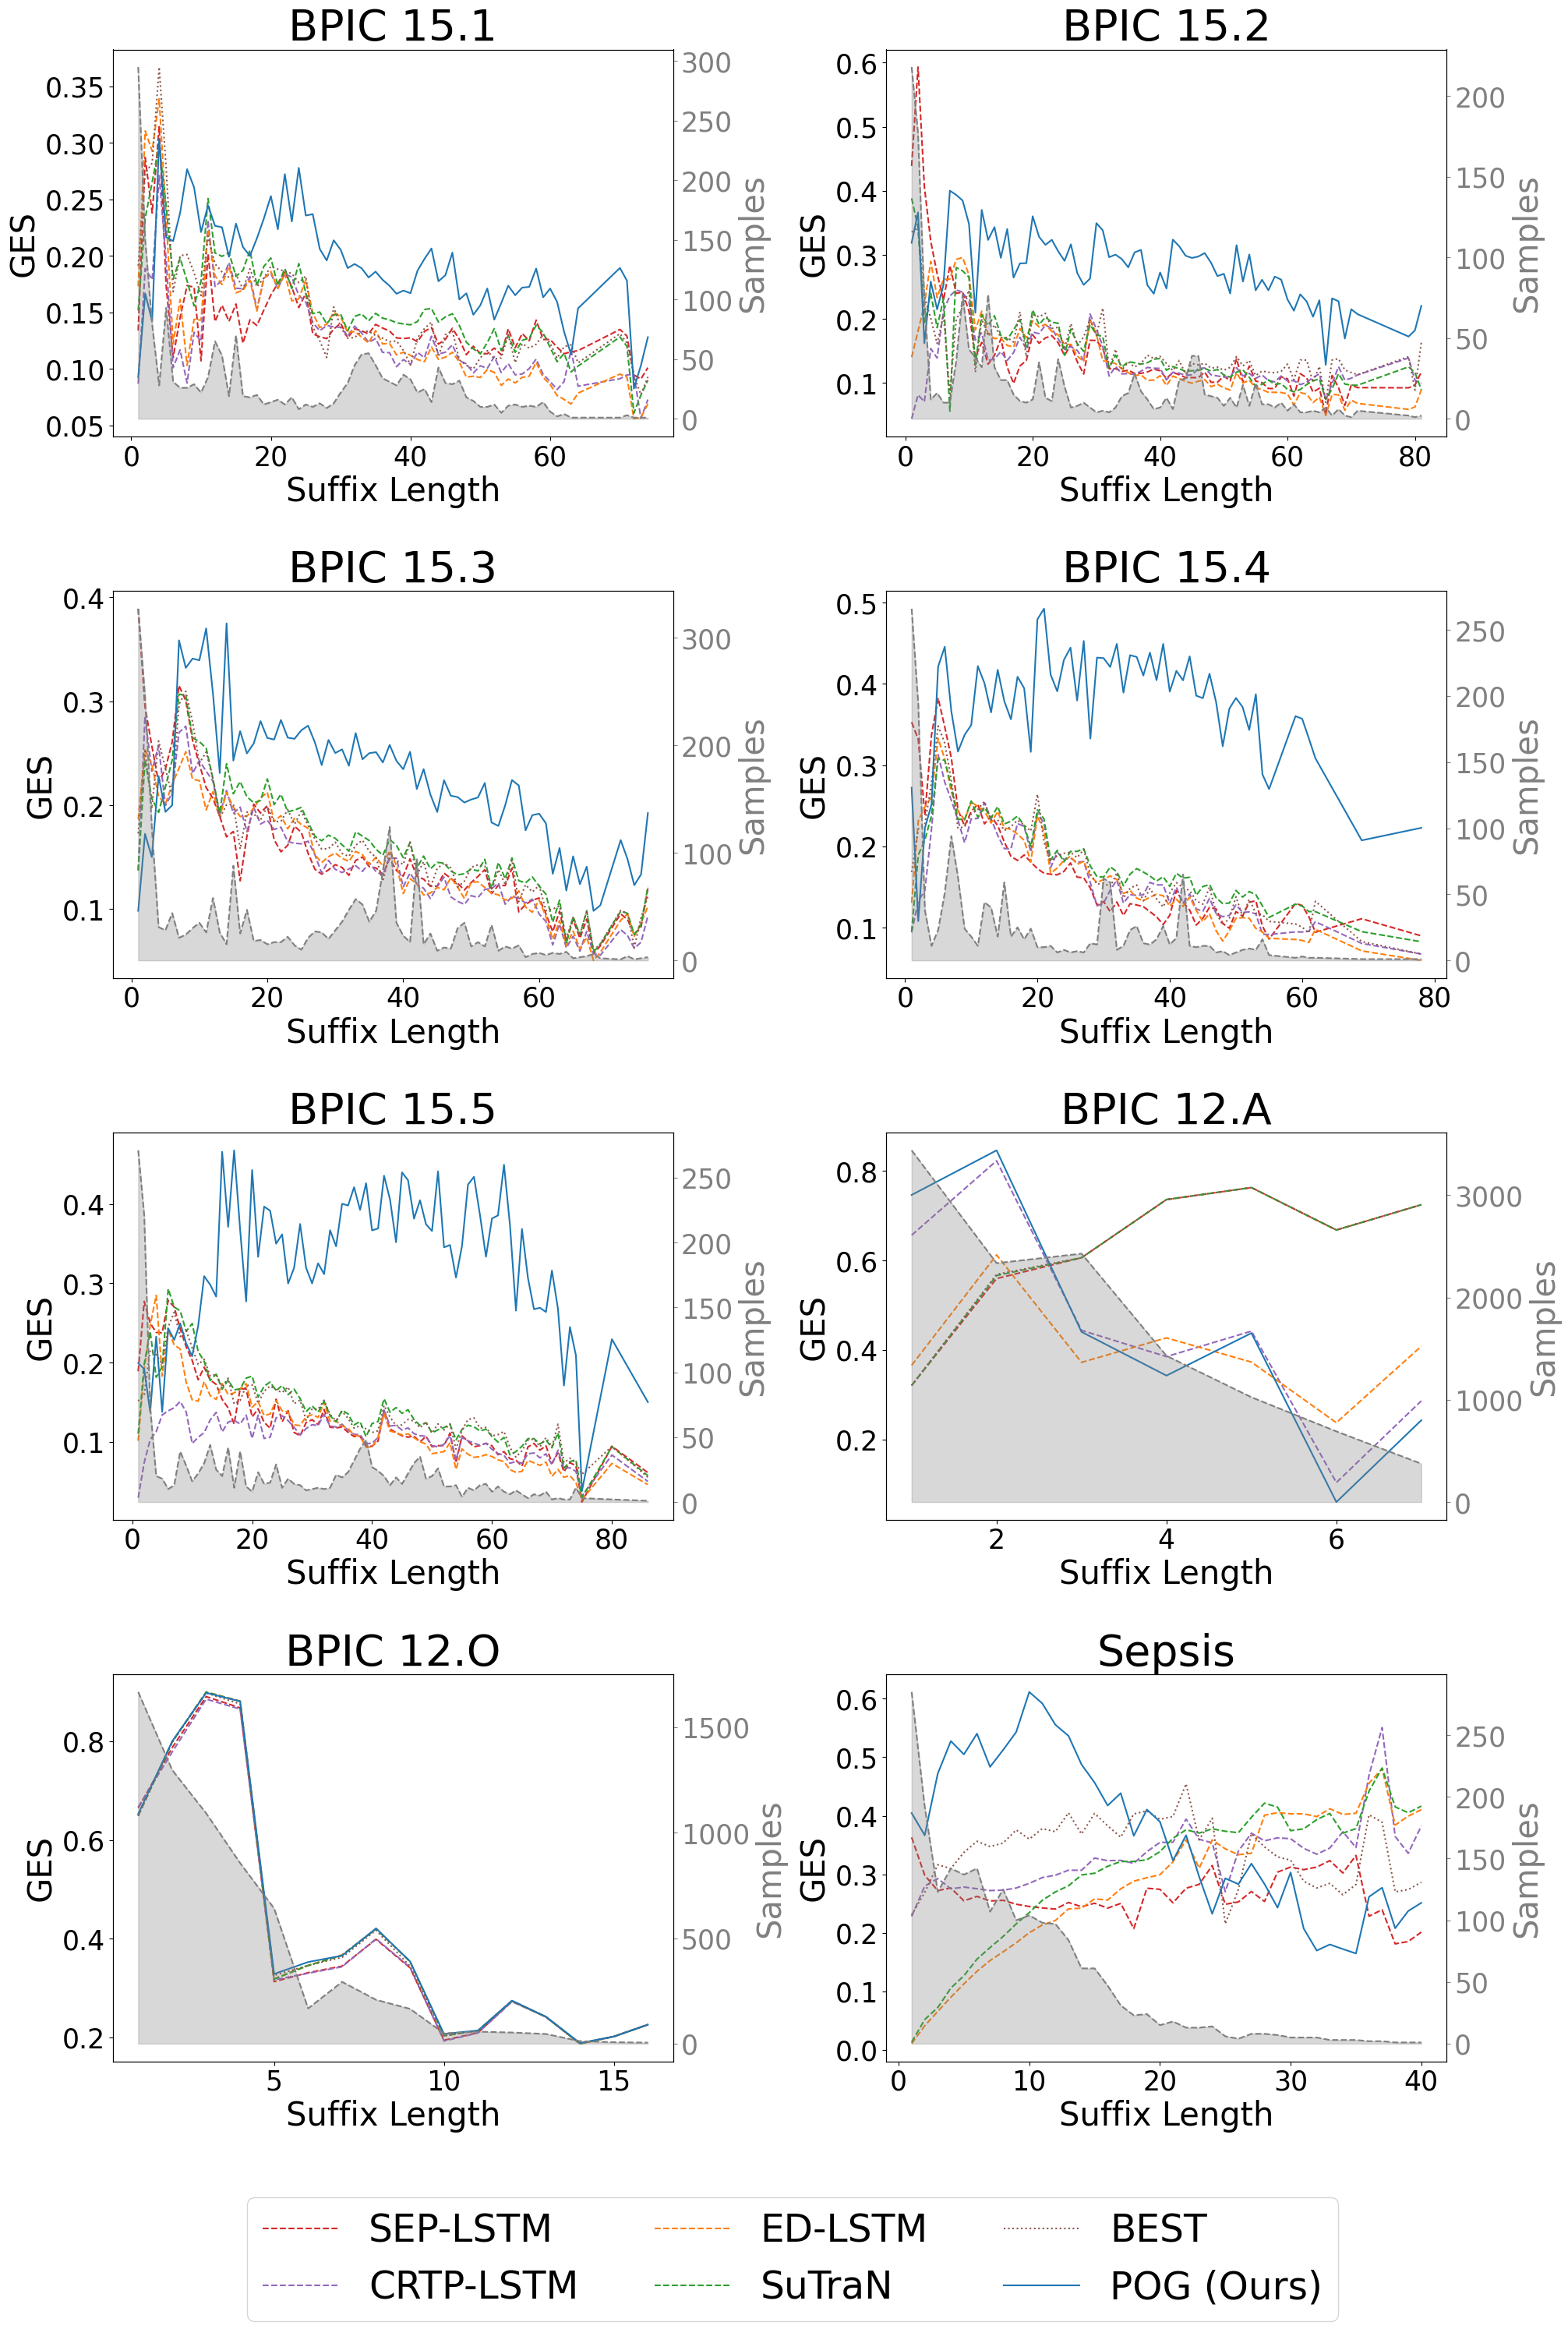

In [2]:
from approach_suffix_v2.visualization.pref_suf_plots_utils import plot_all_logs

EVENT_LOGS = [
    "BPIC15_1",
    "BPIC15_2",
    "BPIC15_3",
    "BPIC15_4",
    "BPIC15_5",
    "BPI_Challenge_2012_A",
    "BPI_Challenge_2012_O",
    "Sepsis",
]

plot_all_logs(
    log_names=EVENT_LOGS,
    baselines_root='baselines/SuffixTransformerNetwork',
    approach_results_base='approach_suffix_v2/results_time_gatv2_gru_nb_v4',
    save_path='approach_suffix_v2/ges_all_logs.pdf',
    metric='ges',
    length_axis='suffix',
    logs_per_row=2,
    approach_key='GATv2_GRU',
    run_ids=(1, 2, 3, 4, 5),
    baselines_to_include=None,
    )

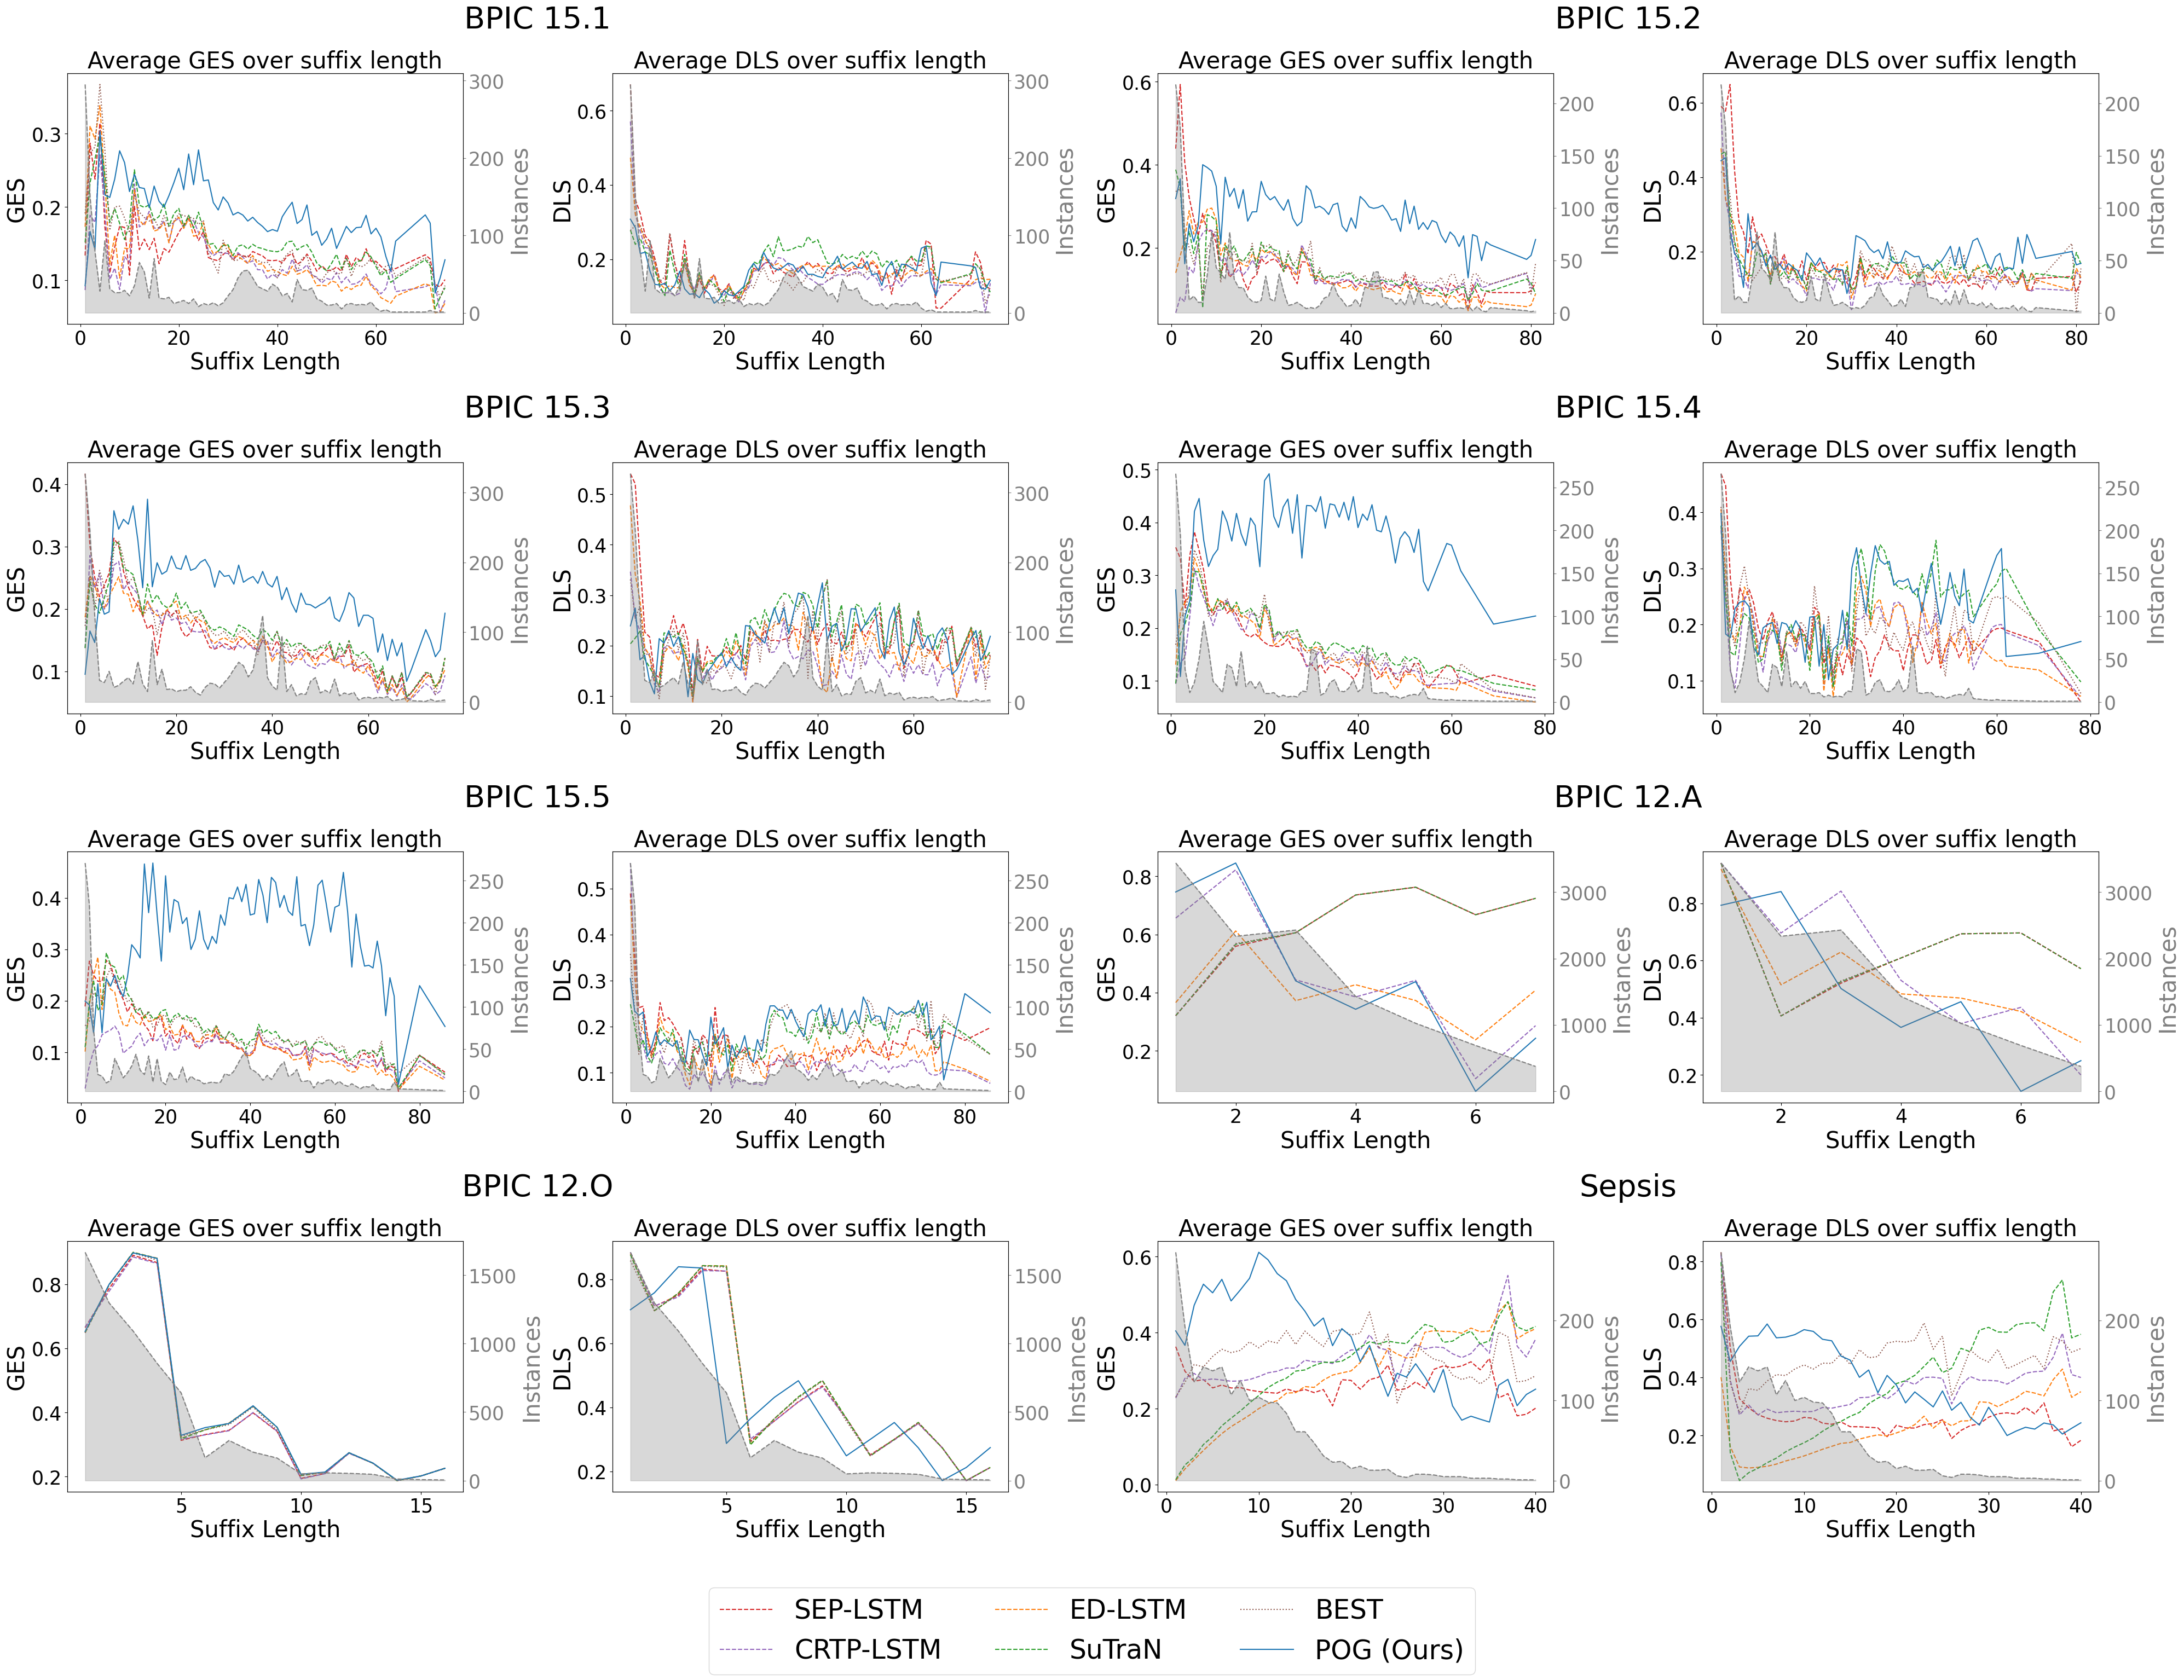

In [1]:
from approach_suffix_v2.visualization.pref_suf_plots_utils import plot_all_logs

EVENT_LOGS = [
    "BPIC15_1",
    "BPIC15_2",
    "BPIC15_3",
    "BPIC15_4",
    "BPIC15_5",
    "BPI_Challenge_2012_A",
    "BPI_Challenge_2012_O",
    "Sepsis",
]

plot_all_logs(
    log_names=EVENT_LOGS,
    baselines_root='baselines/SuffixTransformerNetwork',
    approach_results_base='approach_suffix_v2/results_time_gatv2_gru_nb_v4',
    save_path='approach_suffix_v2/ges_dl_all_logs_v1.pdf',
    metric=['ges', 'dl'],   # a list now works; 'ges' alone still works too
    length_axis='suffix',
    logs_per_row=2,         # 2 → 4 columns, 1 → 2 columns
    approach_key='GATv2_GRU',
    run_ids=(1, 2, 3, 4, 5),
    baselines_to_include=None,
)

## Important notes

 All experimental conditions: split, filtering, vocabulary, and evaluation metric, match the baselines.